In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.data_processing.splitting import split_data
from src.data_processing.esc50_dataset import ESC50Dataset
from src.models.CNN_model import DeepAudioCNN

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")



# Пътища
CSV_PATH = "../data/processed/esc50_segmented.csv"
AUDIO_DIR = "../data/processed/segmented_audio/"
MODEL_PATH = "../models/deep_audio_cnn.pth"

In [ ]:
_, _, test_df = split_data(CSV_PATH)

full_df = pd.read_csv(CSV_PATH)
dummy_dataset = ESC50Dataset(full_df, AUDIO_DIR)
encoder = dummy_dataset.label_encoder

test_dataset = ESC50Dataset(test_df, AUDIO_DIR, label_encoder=encoder)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
model = DeepAudioCNN(n_classes=50).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

DeepAudioCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

In [7]:
all_preds = []
all_labels = []

print("Оценяване на модела върху Тестовия набор...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Оценяване на модела върху Тестовия набор...


In [8]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"🔥 Финална точност на Тестовия сет (Test Accuracy): {test_accuracy * 100:.2f}%\n")

🔥 Финална точност на Тестовия сет (Test Accuracy): 52.49%



In [9]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"🔥 Финална точност на Тестовия сет (Test Accuracy): {test_accuracy * 100:.2f}%\n")

# --- НОВ КОД ЗА PRECISION И RECALL ---
# Взимаме имената на всички 50 класа
all_class_names = encoder.inverse_transform(np.arange(50))

# Генерираме детайлен доклад
report = classification_report(all_labels, all_preds, target_names=all_class_names)

print("📊 ДЕТАЙЛЕН ДОКЛАД (PRECISION, RECALL, F1-SCORE):")
print(report)

🔥 Финална точност на Тестовия сет (Test Accuracy): 52.49%

📊 ДЕТАЙЛЕН ДОКЛАД (PRECISION, RECALL, F1-SCORE):
                  precision    recall  f1-score   support

        airplane       0.05      0.03      0.04        30
       breathing       0.64      0.28      0.39        25
  brushing_teeth       0.93      0.93      0.93        28
     can_opening       0.18      0.18      0.18        11
        car_horn       0.50      0.74      0.60        19
             cat       0.45      0.47      0.46        19
        chainsaw       0.53      0.75      0.62        28
  chirping_birds       0.73      0.39      0.51        28
    church_bells       0.96      0.87      0.91        30
        clapping       0.64      0.27      0.38        26
     clock_alarm       0.81      0.96      0.88        27
      clock_tick       0.88      0.60      0.71        25
        coughing       0.29      0.27      0.28        15
             cow       0.50      0.79      0.61        19
  crackling_fire     

In [10]:
classes_to_show = 50
cm = confusion_matrix(all_labels, all_preds)
cm_subset = cm[:classes_to_show, :classes_to_show]
class_names = encoder.inverse_transform(np.arange(50))[:classes_to_show]

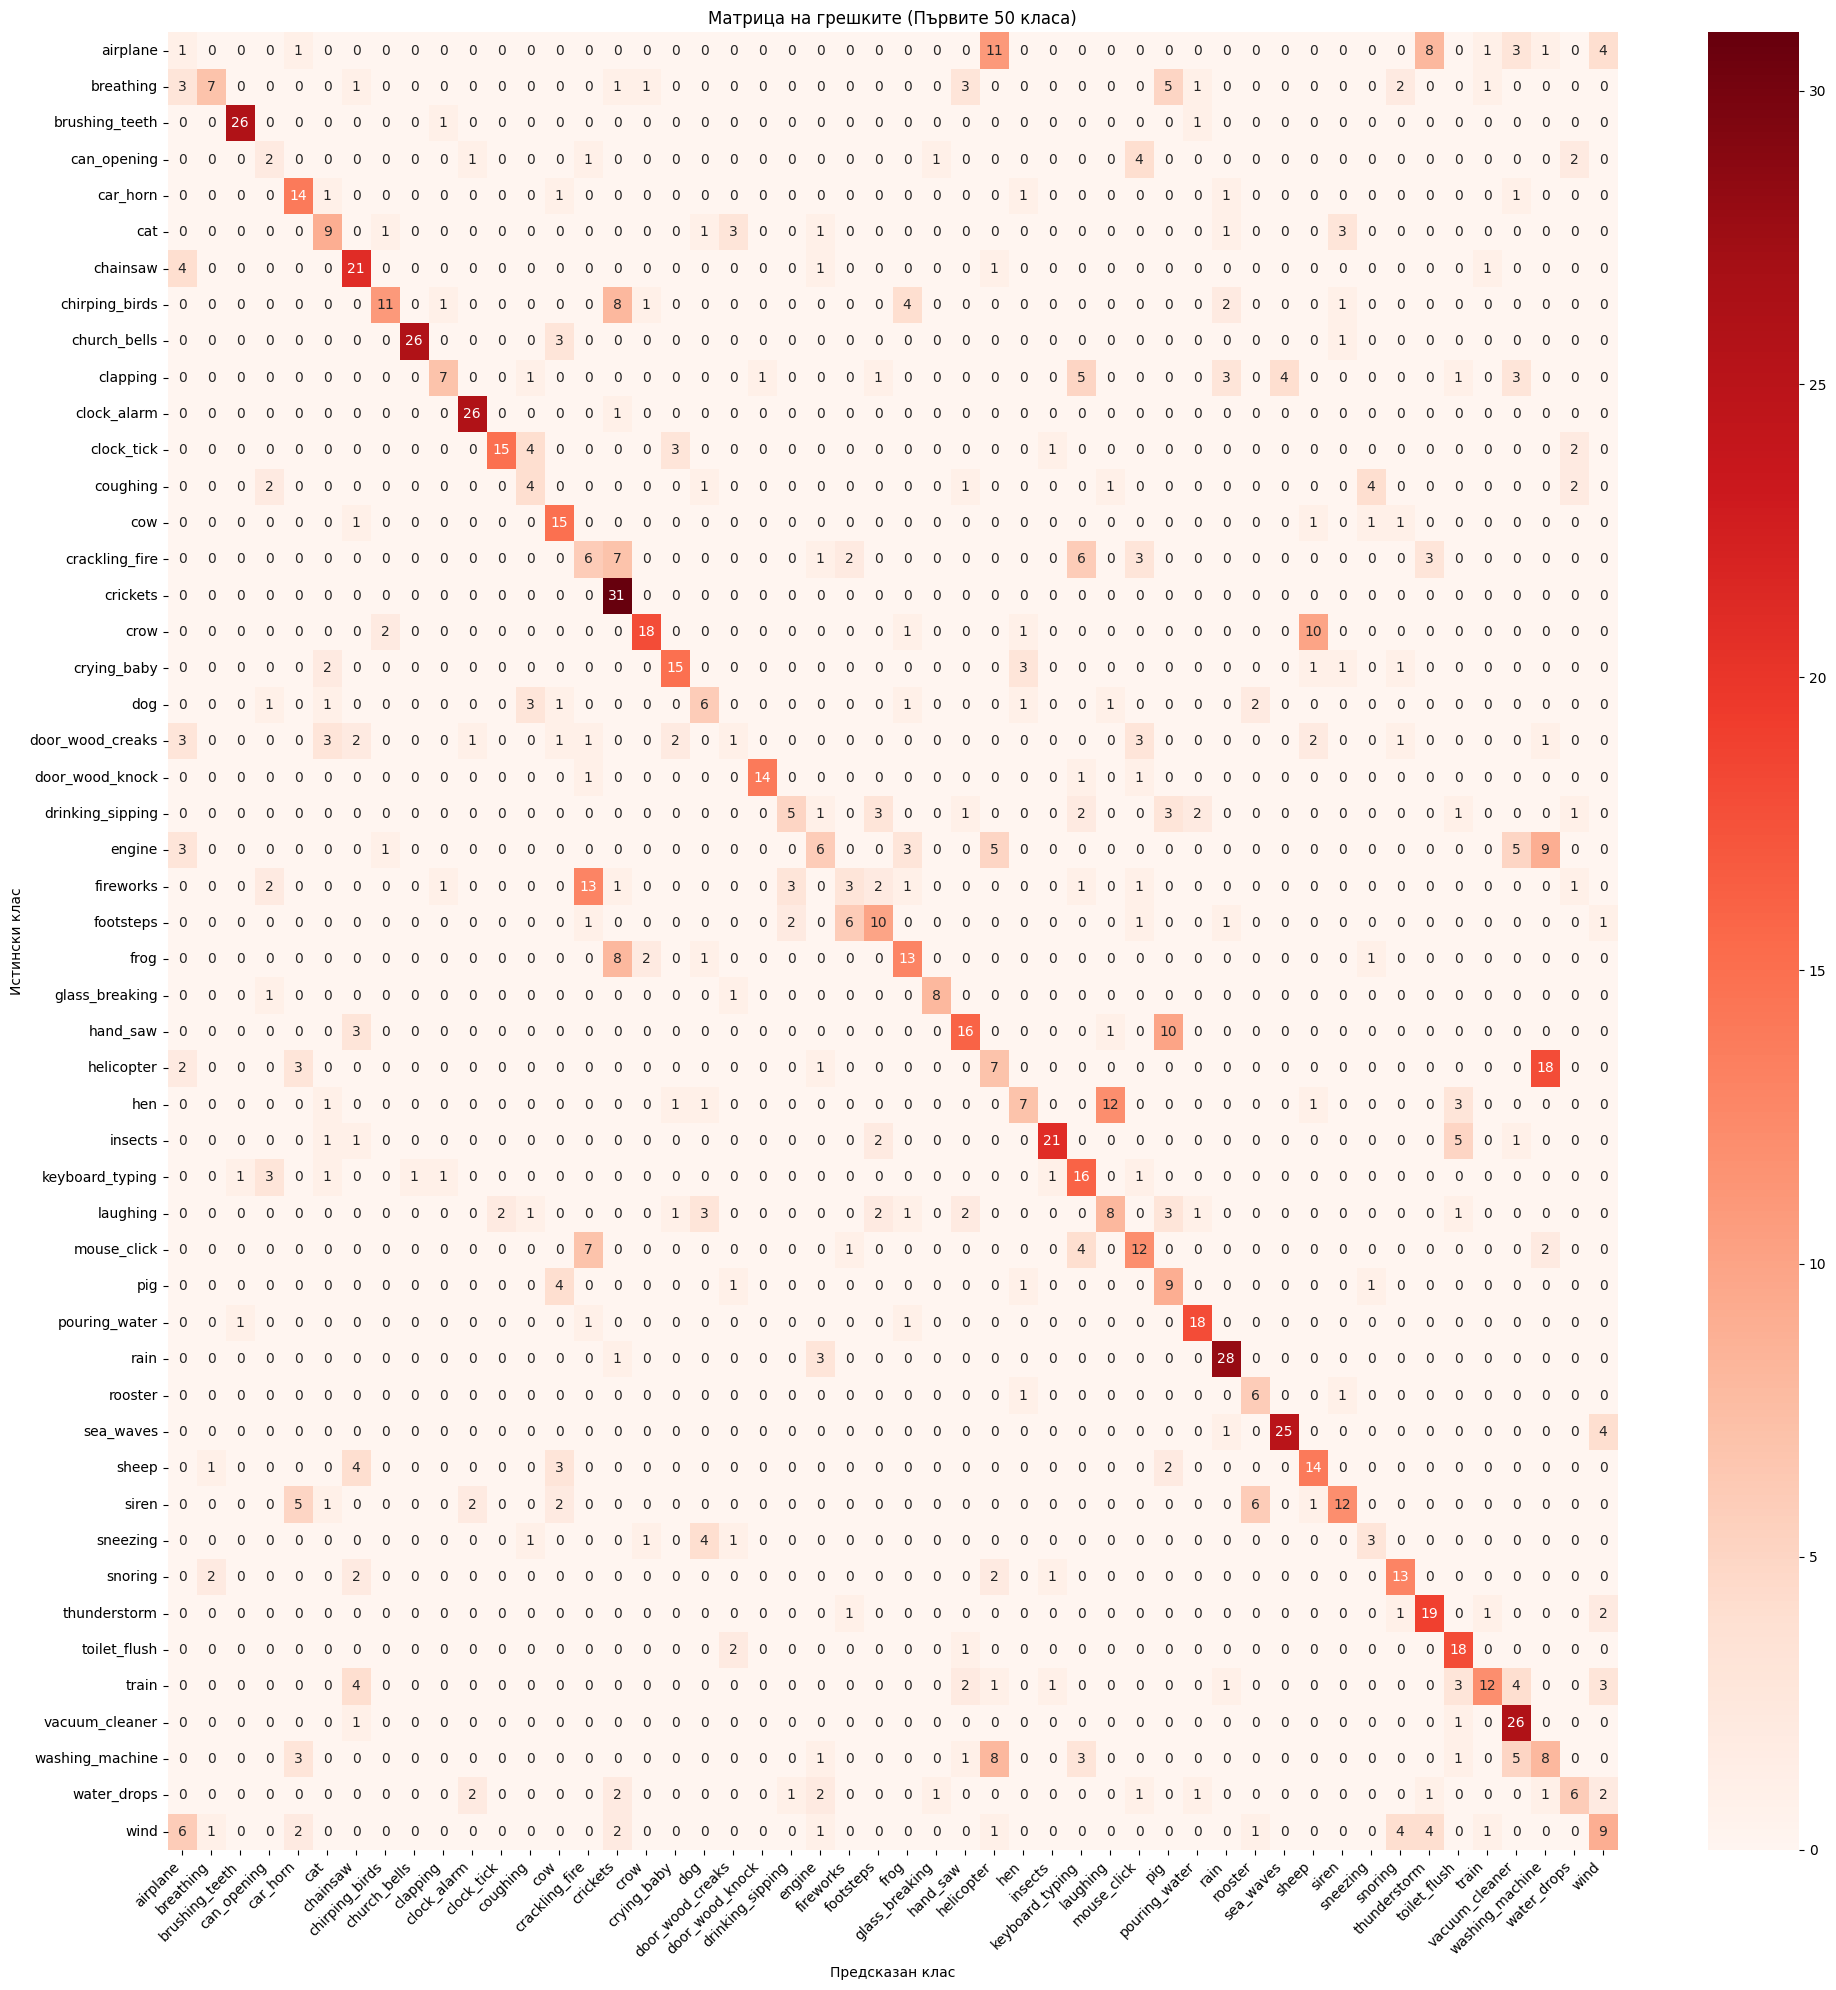

In [11]:
plt.figure(figsize=(20, 20))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Матрица на грешките (Първите {classes_to_show} класа)')
plt.ylabel('Истински клас')
plt.xlabel('Предсказан клас')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

📊 Анализ на резултатите и оценка на модела (DeepAudioCNN)

Финалната оценка на надградената дълбока конволюционна архитектура (DeepAudioCNN с 5 блока) върху напълно непознатия Тестов набор (Fold 5) постигна обща точност от 52.49%. Това представлява абсолютно подобрение от близо 3% спрямо базовата версия. За да се оцени обективно този резултат, трябва да се вземе предвид, че наборът от данни ESC-50 съдържа 50 балансирани класа. При сляпо налучкване (random guessing) очакваната точност е едва 2.0%. Постигнатият резултат доказва категорично, че добавянето на дълбочина в мрежата ѝ позволява да извлича много по-сложни и комплексни времево-честотни характеристики от Мел-спектрограмите.

Детайлният анализ на Доклада за класификация (Classification Report) и Матрицата на грешките (Confusion Matrix) разкрива важни зависимости между по-дълбоката архитектура на модела и физическата природа на звуците:

Класове с висока разделителна способност (High F1-Score)

По-дълбокият модел показва изключителен скок при разпознаването на звуци с бързопроменяща се, комплексна вътрешна структура. Най-високи резултати (F1-score) се наблюдават при:

brushing_teeth (Миене на зъби - 0.93): Изключителен скок спрямо базовата мрежа. Този звук представлява бърза, повтаряща се широколентова фрикция, която само по-дълбоките конволюционни слоеве успяват да изолират.

church_bells (Църковни камбани - 0.91): Продължават да се разпознават почти безпогрешно заради ясните си и продължителни хоризонтални спектрални линии.

clock_alarm (Аларма на часовник - 0.88): Характеризира се със силно изразени, бързи и периодични високочестотни импулси, които 5-те слоя на мрежата улавят и класифицират отлично.

Извод за модела: Дълбоката CNN архитектура успешно извлича сложни йерархични признаци, справяйки се с комплексни текстури и детайли, които бяха невидими за първоначалната плитка мрежа.

Интелигентни акустични грешки (Logical Acoustic Confusions)

Въпреки увеличената дълбочина, анализът на матрицата на грешките показва, че моделът продължава да формира логични "клъстери на объркване". Причината вече не е в капацитета на мрежата, а в ограничението на 2-секундния времеви прозорец:

Широколентов бял шум (Broadband Noise): Класът airplane (самолет) често се класифицира погрешно като wind (вятър). И двата звука представляват широколентов шум. Тяхната енергия е разпределена равномерно, което ги прави визуално идентични при толкова кратък запис без дългосрочен контекст.

Двигатели с вътрешно горене: engine (автомобилен двигател) се бърка с train (влак) и helicopter (хеликоптер). Общото между тях е силната концентрация на енергия в най-ниските честотни ленти (под 500 Hz) и липсата на високочестотни детайли.

Биологични ритмични звуци: Класът breathing (дишане) се бърка системно със snoring (хъркане). Те споделят еднаква времева периодичност (вдишване/издишване), като разликата е само в лекото наличие на вибрация при хъркането.

Високочестотни транзиенти: Пукането на crackling_fire (огън) се бърка с crickets (щурци). И двата класа се изобразяват като серия от много кратки, вертикални високочестотни импулси.

Архитектурни ограничения при слабите класове (Underperforming Classes)

При импулсивните (транзиентни) звуци се забелязва леко подобрение (напр. can_opening се вдига от 0.00 до 0.18), но те остават "ахилесовата пета" на модела. Звуци като door_wood_creaks (скърцане на врата) имат показатели близки до нулата (0.07). Те са кратки събития, които продължават по-малко от 0.5 секунди.

В един 2-секунден прозорец, тези събития заемат много малък процент от пикселите на спектрограмата.

Операциите MaxPool2d и най-вече AdaptiveAvgPool2d (Global Average Pooling) в нашата архитектура усредняват стойностите по цялата площ на тензора. При много кратки звуци, усредняването буквално "изтрива" техния сигнал, макар по-дълбоките слоеве да успяват да спасят малка част от него.

Заключение и бъдещи насоки (Overfitting & Transfer Learning)

Достигнатата точност от ~52.5% разкрива класически парадокс в дълбокото обучение. По време на тренировка, точността доближи 95%, докато тестовата се стабилизира много по-ниско. Това означава, че мрежата страда от силно Преобучаване (Overfitting). Архитектурата е станала твърде "голяма" за наличните 8000 аудио сегмента и започва да наизустява данните, вместо да ги генерализира.

За преодоляване на този проблем с липсата на достатъчно данни и достигане на индустриални стандарти (точност >80%), логичната следваща стъпка е използването на Трансферно обучение (Transfer Learning) – интегриране на готови дълбоки архитектури (като ResNet-18), предварително обучени върху милиони изображения. Те вече притежават необходимите филтри за разпознаване на текстури и ще предотвратят преобучаването върху нашия малък набор от данни.